In [1]:
from datetime import datetime
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from datetime import timedelta
import matplotlib.pyplot as plt

timedelta_threshold_seconds = timedelta(days=20).total_seconds()

def make_training_set(n_shifts):
    filepath_train = r'../datasets/ais_train.csv'
    filepath_test = r'../datasets/ais_test.csv'

    # Load AIS historical data
    train = pd.read_csv(filepath_train, sep ='|')  # Replace with your dataset
    test = pd.read_csv(filepath_test, sep = ',')

    # Preprocessing
    train['time'] = pd.to_datetime(train['time'])
    train.sort_values(by=['vesselId', 'time'], inplace=True)
    train['isMoored'] = train['navstat']== 5
    # Why are we using the complement?
    train = train[~train['isMoored']]

    test['time'] = pd.to_datetime(test['time'])
    test.sort_values(by=['vesselId', 'time'], inplace=True)

    # Feature Engineering
    train['prev_lat'] = train.groupby('vesselId')['latitude'].shift(n_shifts)
    train['prev_lon'] = train.groupby('vesselId')['longitude'].shift(n_shifts)
    train['prev_speed'] = train.groupby('vesselId')['sog'].shift(n_shifts)
    train['prev_course'] = (train.groupby('vesselId')['cog'].shift(n_shifts) / 180) - 1        # normalized
    train['prev_rotation'] = train.groupby('vesselId')['rot'].shift(n_shifts) 
    train['prev_heading'] = (train.groupby('vesselId')['heading'].shift(n_shifts)/ 180) - 1 
    # Adding timedelta as a feature
    train['time_diff'] = train['time'].diff(n_shifts)
    train['time_diff_seconds'] = train['time_diff'].dt.total_seconds()
    # Apply the moving average function to each vessel group
    train.dropna(inplace=True)

    # --------------------------------- prev_rot-related stuff
    # Replace special values with NaN
    train['prev_rotation'] = train['prev_rotation'].replace({127: np.nan, -127: np.nan, -128: np.nan})
    train['prev_speed'] = train['prev_speed'].replace({102.3: np.nan})
    train['prev_course'] = train['prev_course'].replace({360: np.nan})
    train['prev_heading'] = train['prev_heading'].replace({511: np.nan})
    train.dropna(inplace=True)

    train = train[train['time_diff_seconds'] <= timedelta_threshold_seconds]

    # # Fill missing values (optional, using forward fill) Uses most recent non-null value from the row above.
    # train['prev_rotation'].fillna(method='ffill', inplace=True)

    # Drop rows with missing values
    train.dropna(inplace=True)

    print(f"Length of dataset after preprocessing: {len(train)}")
    return train
    

train1 = make_training_set(1)
train2 = make_training_set(2)
train3 = make_training_set(3)
train4 = make_training_set(4)
train5 = make_training_set(5)
train6 = make_training_set(6)
train7 = make_training_set(7)
# train8 = make_training_set(8)
# train9 = make_training_set(9)
# train10 = make_training_set(10)
# train11 = make_training_set(11)
# train12 = make_training_set(12)
# train13 = make_training_set(13)
# train14 = make_training_set(14)
# train15 = make_training_set(15)
# train16 = make_training_set(16)
# train17 = make_training_set(17)
# train18 = make_training_set(18)
# train19 = make_training_set(19)
# train20 = make_training_set(20)
train21 = make_training_set(21)
train22 = make_training_set(22)
train23 = make_training_set(23)
# train24 = make_training_set(24)
# train25 = make_training_set(25)
# train26 = make_training_set(26)

# train24 = make_training_set(24)

train34 = make_training_set(34)

train44 = make_training_set(44)

train46 = make_training_set(46)

train48 = make_training_set(48)

train50 = make_training_set(50)
train51 = make_training_set(51)
train52 = make_training_set(52)
# train53 = make_training_set(53)
train54 = make_training_set(54)
train55 = make_training_set(55)
train56 = make_training_set(56)
# train57 = make_training_set(57)
train58 = make_training_set(58)
# train59 = make_training_set(59)
train60 = make_training_set(60)

train62 = make_training_set(62)

train64 = make_training_set(64)

train74 = make_training_set(74)

train84 = make_training_set(84)

# train60 = make_training_set(60)

# train70 = make_training_set(70)
# train71 = make_training_set(71)
# train72 = make_training_set(72)
# train73 = make_training_set(73)
# train74 = make_training_set(74)
# train75 = make_training_set(75)

# train80 = make_training_set(80)
# train81 = make_training_set(81)
# train82 = make_training_set(82)
# train83 = make_training_set(83)
# train84 = make_training_set(84)
# train85 = make_training_set(85)
# train86 = make_training_set(86)
# train87 = make_training_set(87)
# train88 = make_training_set(88)
# train89 = make_training_set(89)
# train90 = make_training_set(90)
# train91 = make_training_set(91)
# train92 = make_training_set(92)
# train93 = make_training_set(93)
# train94 = make_training_set(94)
# train95 = make_training_set(95)
# train96 = make_training_set(96)
# train97 = make_training_set(97)
# train98 = make_training_set(98)

train100 = make_training_set(100)
train101 = make_training_set(101)
train102 = make_training_set(102)

# train100 = make_training_set(100)
# train101 = make_training_set(101)
# train102 = make_training_set(102)
# train103 = make_training_set(103)
# train104 = make_training_set(104)
# train105 = make_training_set(105)
# train106 = make_training_set(106)
# train107 = make_training_set(107)
# train108 = make_training_set(108)
# train109 = make_training_set(109)
# train110 = make_training_set(110)
# train111 = make_training_set(111)
# train112 = make_training_set(112)
# train113 = make_training_set(113)
# train114 = make_training_set(114)
# train115 = make_training_set(115)

# train = pd.concat([train8, train9, train10, train11, train12, train13, train14], ignore_index=True)
# train = pd.concat([train88, train89, train90, train91, train92, train93, train94, train95, train96, train97, train98], ignore_index=True)
# train = pd.concat([train80, train81, train82, train83, train84, train85, train86, train87, train88, train89, train90], ignore_index=True)
# train = pd.concat([train50, train51, train52, train53, train54, train55, train56, train57, train58, train59, train60], ignore_index=True)
# train = pd.concat([train3, train4, train5, train6, train7, train21, train22, train23, train50, train51, train52, train100, train101, train102], ignore_index=True)
# train = pd.concat([train3, train4, train5, train6, train7, train21, train22, train23, train50, train51, train52, train100, train101, train102], ignore_index=True)
train = pd.concat([train1, train2, train3, train4, train5, train34, train44, train46, train48, train50, train52, train54, train55, train56, train58, train60, train62, train64, train74, train84])

# train = pd.concat([train1, train2, train3, train4, train5, train6, train7,train8, train9, train10, train11, train12, train13, train14], ignore_index=True)

feats_to_include = ['prev_lat', 'prev_lon', 'prev_speed', 'prev_course','prev_rotation', 'prev_heading', 'time_diff_seconds']
X = train[feats_to_include]
y_lat = train['latitude']
y_lon = train['longitude']

print(f"Here comes X[time diff seconds].describe:\n{X['time_diff_seconds'].describe()}")

Length of dataset after preprocessing: 892825
Length of dataset after preprocessing: 891890
Length of dataset after preprocessing: 890950
Length of dataset after preprocessing: 889996
Length of dataset after preprocessing: 889023
Length of dataset after preprocessing: 888051
Length of dataset after preprocessing: 887051
Length of dataset after preprocessing: 871034
Length of dataset after preprocessing: 869719
Length of dataset after preprocessing: 868413
Length of dataset after preprocessing: 852662
Length of dataset after preprocessing: 836860
Length of dataset after preprocessing: 833598
Length of dataset after preprocessing: 830325
Length of dataset after preprocessing: 826927
Length of dataset after preprocessing: 825207
Length of dataset after preprocessing: 823503
Length of dataset after preprocessing: 820065
Length of dataset after preprocessing: 818322
Length of dataset after preprocessing: 816548
Length of dataset after preprocessing: 813026
Length of dataset after preprocess

In [ ]:
time_diff_data_X = X['time_diff_seconds']
print(f"Length of dataset: {len(X)}")
print(f"mean: {np.mean(time_diff_data_X)}\nStd: {np.std(time_diff_data_X)}")
time_diff_data_X.plot(kind='kde')
plt.xlim(0, 1e6)
plt.xlabel('Value')
plt.title('Density Plot of data_column')
plt.show()

Length of dataset: 16692421
mean: 228949.01253520985
Std: 325311.9703342315


In [9]:

import pandas as pd
from tqdm import tqdm
from datetime import datetime

filepath_train = r'../datasets/ais_train.csv'

# Load AIS historical data
training_data = pd.read_csv(filepath_train, sep='|')
training_data['time'] = pd.to_datetime(training_data['time'])

# Predict future positions
def get_latest_datapoint(vessel_id):
    # Fetch the latest known position of the vessel
    latest_data_points = training_data[training_data['vesselId'] == vessel_id]
    latest_data_points_sorted = latest_data_points.sort_values(by='time')
    latest_data_points_sorted = latest_data_points_sorted.set_index('time')
    latest_data_point = latest_data_points_sorted.iloc[-1]
    return latest_data_point.name

time_diffs = {}
latest_datapoints = {}
# Open the test file for reading and the prediction file for writing
with open('../datasets/ais_test.csv', 'r') as f_test, open('../.csv', 'w') as f_pred:
    for line in tqdm(f_test.readlines()[1:]):
        id, vesselId, time, scaling_factor = line.split(',')
        if not vesselId in time_diffs.keys():
            latest_datapoint = get_latest_datapoint(vesselId)
            latest_datapoints[vesselId] = latest_datapoint
            time_diffs[vesselId] = [pd.to_datetime(time) - latest_datapoint]
        else:
            time_diffs[vesselId].append(pd.to_datetime(time) - latest_datapoints[vesselId])


100%|██████████| 51739/51739 [00:40<00:00, 1264.95it/s]


In [13]:
from itertools import chain
time_diffs_merged = list(chain(*time_diffs.values()))
time_diffs_sec_merged = [v.total_seconds() for v in time_diffs_merged]
print(len(time_diffs_merged))

51739


Mean: 304764.71
Standard Deviation: 330886.14
25th Percentile: 122351.00
Median (50th Percentile): 239565.00
75th Percentile: 361008.50


C:\Users\mariu\AppData\Local\Temp\ipykernel_44008\549297256.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(time_diffs_sec_merged, shade=True)


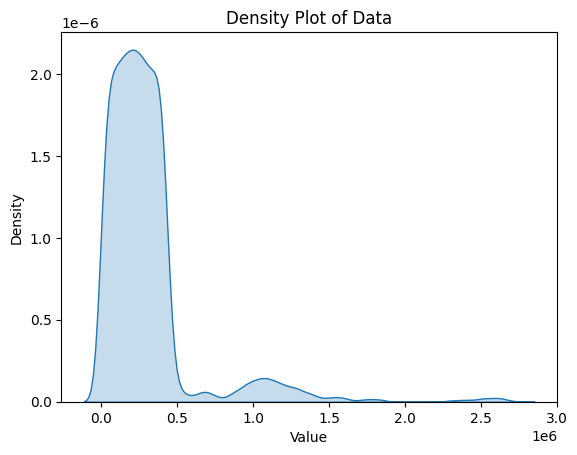

In [14]:
import seaborn as sns

# Calculate statistics
mean = np.mean(time_diffs_sec_merged)
std_dev = np.std(time_diffs_sec_merged)
percentiles = np.percentile(time_diffs_sec_merged, [25, 50, 75])  # 25th, 50th (median), and 75th percentiles

# Print the statistics
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"25th Percentile: {percentiles[0]:.2f}")
print(f"Median (50th Percentile): {percentiles[1]:.2f}")
print(f"75th Percentile: {percentiles[2]:.2f}")

# Plot density
sns.kdeplot(time_diffs_sec_merged, shade=True)
plt.xlabel('Value')
plt.title('Density Plot of Data')
plt.savefig("simple_density_plot_test_data.png")
plt.show()


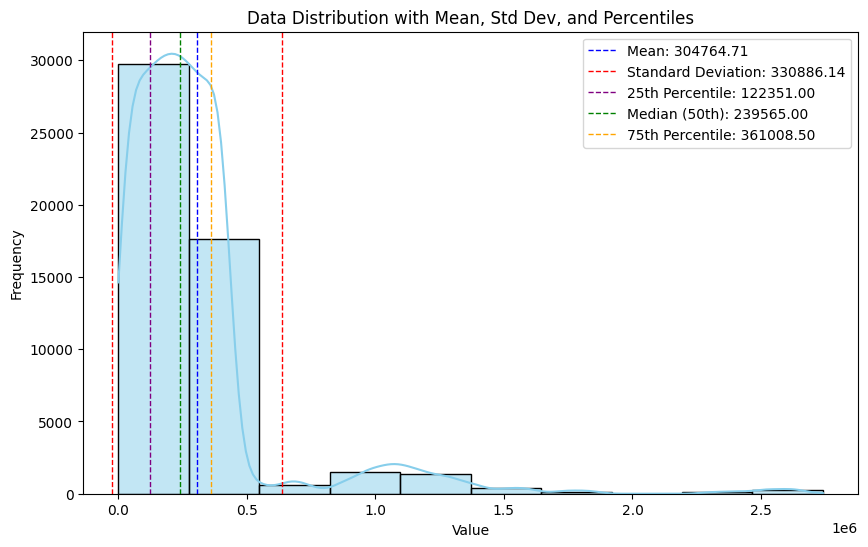

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate statistics
mean = np.mean(time_diffs_sec_merged)
std_dev = np.std(time_diffs_sec_merged)
percentiles = np.percentile(time_diffs_sec_merged, [25, 50, 75])  # 25th, 50th (median), and 75th percentiles

# Plot histogram and density plot
plt.figure(figsize=(10, 6))
sns.histplot(time_diffs_sec_merged, bins=10, kde=True, color="skyblue", edgecolor="black")
plt.axvline(mean, color='blue', linestyle='--', linewidth=1, label=f'Mean: {mean:.2f}')
plt.axvline(mean + std_dev, color='red', linestyle='--', linewidth=1, label=f'Standard Deviation: {std_dev:.2f}')
plt.axvline(mean - std_dev, color='red', linestyle='--', linewidth=1)
plt.axvline(percentiles[0], color='purple', linestyle='--', linewidth=1, label=f'25th Percentile: {percentiles[0]:.2f}')
plt.axvline(percentiles[1], color='green', linestyle='--', linewidth=1, label=f'Median (50th): {percentiles[1]:.2f}')
plt.axvline(percentiles[2], color='orange', linestyle='--', linewidth=1, label=f'75th Percentile: {percentiles[2]:.2f}')

# Labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Data Distribution with Mean, Std Dev, and Percentiles')
plt.legend()
plt.savefig("histplot_w_percentiles_test_data.png")
plt.show()

